# Stages 6–8: Long-stay prediction model development

**Question:** Can intake-time information identify animals likely to remain in the shelter for at least 30 days? The positive class is `long_stay_30 = 1`.

Run this notebook from top to bottom with the supplied CSV in the same folder. It audits the data, compares four suitable algorithms, tunes promising models, tests feature choices, selects a decision threshold, evaluates the untouched test set once, and records evidence for Progress Evaluation 2.

Install first in your notebook environment if needed: `%pip install pandas numpy scipy scikit-learn matplotlib joblib`. Restart the kernel after installation.

**Evaluation rule:** use training data to fit and cross-validate; use validation data to compare choices and choose a threshold; use test data only in the final evaluation cell. Average precision (PR-AUC) is the main ranking metric. Also report balanced accuracy, positive-class precision/recall/F1, ROC-AUC, and ordinary accuracy. A majority-class dummy is essential because 81.22% test accuracy is achievable without detecting any long stays.

In [1]:
from pathlib import Path
import json
import time
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, average_precision_score,
                             balanced_accuracy_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, TimeSeriesSplit
from sklearn.svm import LinearSVC

RANDOM_STATE = 42
DATA_PATH = Path('KND_04_Preprocessed_All_Splits_With_Labels.csv')
CV_MODE = 'stratified'  # Set to 'temporal' ONLY if source_row_number truly follows intake time.
SEARCH_ITERATIONS = 10  # Increase to 25–50 if time permits.
assert DATA_PATH.exists(), f'Missing {DATA_PATH.resolve()}'
print('Data:', DATA_PATH.resolve())
print('Cross-validation mode:', CV_MODE)

Data: C:\Users\ravin\Downloads\stage6\KND_04_Preprocessed_All_Splits_With_Labels.csv
Cross-validation mode: stratified


## 1. Data audit and fixed splits
`split` and `source_row_number` are metadata, never predictors. The CSV was already preprocessed; verify separately that scaling, imputation, rare-category rules, and one-hot categories were learned from training records only. This notebook cannot prove that from the final CSV. The separated row ranges suggest an ordered split, but row number alone does not prove chronological order. Choose `CV_MODE` accordingly.

In [2]:
df = pd.read_csv(DATA_PATH)
required = {'split', 'source_row_number', 'long_stay_30'}
assert required.issubset(df.columns)
assert set(df['split']) == {'train', 'validation', 'test'}
assert set(df['long_stay_30'].unique()) == {0, 1}
assert df['source_row_number'].is_unique, 'Duplicate source row identifiers need investigation.'
assert not df.isna().any().any(), 'Missing values need investigation.'
feature_cols = [c for c in df if c not in required]
assert all(pd.api.types.is_numeric_dtype(df[c]) for c in feature_cols)
train_df = df.loc[df['split'].eq('train')].sort_values('source_row_number').copy()
val_df = df.loc[df['split'].eq('validation')].sort_values('source_row_number').copy()
test_df = df.loc[df['split'].eq('test')].sort_values('source_row_number').copy()
constant_cols = [c for c in feature_cols if train_df[c].nunique(dropna=False) <= 1]
feature_cols = [c for c in feature_cols if c not in constant_cols]
X_train, y_train = train_df[feature_cols], train_df['long_stay_30'].astype(int)
X_val, y_val = val_df[feature_cols], val_df['long_stay_30'].astype(int)
X_test, y_test = test_df[feature_cols], test_df['long_stay_30'].astype(int)
audit = df.groupby('split', sort=False)['long_stay_30'].agg(n='size', positives='sum', prevalence='mean')
audit['majority_accuracy'] = np.maximum(audit['prevalence'], 1 - audit['prevalence'])
display(audit.style.format({'prevalence': '{:.2%}', 'majority_accuracy': '{:.2%}'}))
print(f'{len(df):,} rows; {len(feature_cols)} usable features; {len(constant_cols)} train-constant columns removed')
print('Removed constant columns:', constant_cols)
display(df.groupby('split')['source_row_number'].agg(['min', 'max']))

,n,positives,prevalence,majority_accuracy
split,,,,
train,6096,1912,31.36%,68.64%
validation,1163,245,21.07%,78.93%
test,1672,314,18.78%,81.22%


8,931 rows; 183 usable features; 10 train-constant columns removed
Removed constant columns: ['categories__type_UNKNOWN', 'categories__type___RARE_OR_NEW__', 'categories__breed_UNKNOWN', 'categories__color_UNKNOWN', 'categories__biological_sex___RARE_OR_NEW__', 'categories__intake_type_UNKNOWN', 'categories__intake_type___RARE_OR_NEW__', 'categories__intake_subtype_UNKNOWN', 'categories__intake_condition___RARE_OR_NEW__', 'categories__intake_jurisdiction___RARE_OR_NEW__']


,min,max
split,,
test,8019,9696
train,1,6292
validation,6598,7802


## 2. Validation and shared evaluation code
The held-out validation and test sets are never used inside hyperparameter search. Stratified folds preserve class proportions within training. If intake time ordering is confirmed, use expanding time folds instead and keep rows sorted by intake time. A model's `score` is a positive-class probability or decision value; average precision and ROC-AUC work with either.

In [3]:
if CV_MODE == 'temporal':
    cv = TimeSeriesSplit(n_splits=3)
elif CV_MODE == 'stratified':
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
else:
    raise ValueError('CV_MODE must be stratified or temporal')

def positive_score(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)

def metric_row(y, scores, predictions, label, stage, seconds=np.nan):
    return {'stage': stage, 'model': label, 'n': len(y),
            'accuracy': accuracy_score(y, predictions),
            'balanced_accuracy': balanced_accuracy_score(y, predictions),
            'precision_1': precision_score(y, predictions, zero_division=0),
            'recall_1': recall_score(y, predictions, zero_division=0),
            'f1_1': f1_score(y, predictions, zero_division=0),
            'roc_auc': roc_auc_score(y, scores),
            'average_precision': average_precision_score(y, scores),
            'fit_seconds': seconds}

def evaluate_fitted(model, X, y, label, stage, seconds=np.nan):
    return metric_row(y, positive_score(model, X), model.predict(X), label, stage, seconds)

def show_results(rows):
    cols = ['stage', 'model', 'accuracy', 'balanced_accuracy', 'precision_1',
            'recall_1', 'f1_1', 'roc_auc', 'average_precision', 'fit_seconds']
    display(pd.DataFrame(rows)[cols].sort_values('average_precision', ascending=False)
            .style.format({c: '{:.3f}' for c in cols[2:-1]} | {'fit_seconds': '{:.1f}'}))

experiment_rows = []

## 3. Stage 6: four baseline algorithms
Logistic regression is an interpretable linear baseline. Linear SVM suits many one-hot columns. Random forest captures interactions with bagged trees. Histogram gradient boosting fits nonlinear effects with boosting. The dummy model shows the class-imbalance trap and does not count as one of the four algorithms.

In [4]:
baseline_specs = {
    'Dummy majority': DummyClassifier(strategy='most_frequent'),
    'Logistic regression': LogisticRegression(C=1.0, solver='liblinear', max_iter=3000, random_state=RANDOM_STATE),
    'Linear SVM': LinearSVC(C=1.0, max_iter=10000, random_state=RANDOM_STATE),
    'Random forest': RandomForestClassifier(n_estimators=250, min_samples_leaf=3,
                                            class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE),
    'Gradient boosting': HistGradientBoostingClassifier(max_iter=180, max_leaf_nodes=15,
                                                         l2_regularization=1.0, random_state=RANDOM_STATE)
}
baseline_models = {}
for name, specification in baseline_specs.items():
    start = time.perf_counter()
    model = clone(specification).fit(X_train, y_train)
    seconds = time.perf_counter() - start
    baseline_models[name] = model
    experiment_rows.append(evaluate_fitted(model, X_train, y_train, name, 'baseline train', seconds))
    experiment_rows.append(evaluate_fitted(model, X_val, y_val, name, 'baseline validation', seconds))
show_results([r for r in experiment_rows if r['stage'] == 'baseline validation'])
print('Compare training and validation below; a large gap suggests overfitting.')
display(pd.DataFrame(experiment_rows).pivot(index='model', columns='stage', values='average_precision').round(3))

,stage,model,accuracy,balanced_accuracy,precision_1,recall_1,f1_1,roc_auc,average_precision,fit_seconds
4,baseline validation,Gradient boosting,0.713,0.655,0.377,0.555,0.449,0.713,0.375,1.1
3,baseline validation,Random forest,0.670,0.656,0.345,0.633,0.447,0.703,0.361,1.0
1,baseline validation,Logistic regression,0.711,0.620,0.356,0.461,0.402,0.690,0.350,0.0
2,baseline validation,Linear SVM,0.704,0.609,0.344,0.445,0.388,0.680,0.343,0.0
0,baseline validation,Dummy majority,0.789,0.500,0.000,0.000,0.000,0.500,0.211,0.0


Compare training and validation below; a large gap suggests overfitting.


stage,baseline train,baseline validation
model,,
Dummy majority,0.314,0.211
Gradient boosting,0.856,0.375
Linear SVM,0.702,0.343
Logistic regression,0.703,0.350
Random forest,0.859,0.361


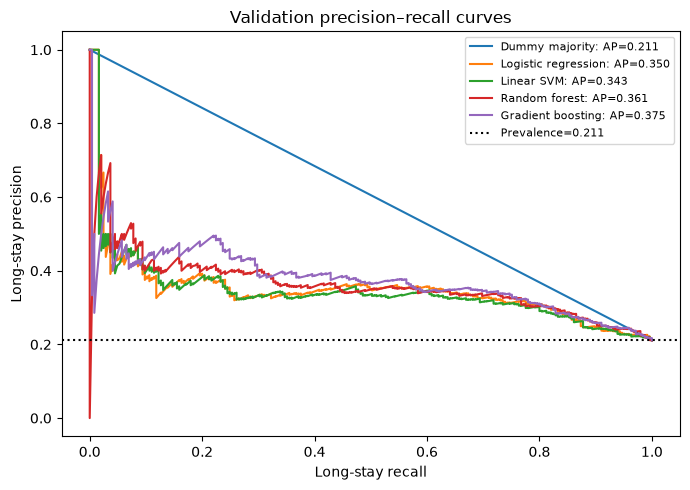

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, model in baseline_models.items():
    precision, recall, _ = precision_recall_curve(y_val, positive_score(model, X_val))
    ap = average_precision_score(y_val, positive_score(model, X_val))
    ax.plot(recall, precision, label=f'{name}: AP={ap:.3f}')
ax.axhline(y_val.mean(), color='black', linestyle=':', label=f'Prevalence={y_val.mean():.3f}')
ax.set(xlabel='Long-stay recall', ylabel='Long-stay precision', title='Validation precision–recall curves')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Stage 7: hyperparameter search
Search three suitable models with cross-validation on training data only. The search score is average precision. These ranges control regularization, tree complexity, and class weighting. Set `SEARCH_ITERATIONS` higher for a more thorough run; record the value used. Linear SVM remains a baseline comparator.

In [6]:
search_spaces = {
    'Logistic regression': {
        'C': [0.01, 0.03, 0.1, 0.3, 1, 3, 10],
        'penalty': ['l1', 'l2'], 'class_weight': [None, 'balanced']},
    'Random forest': {
        'n_estimators': [150, 250, 400], 'max_depth': [None, 8, 16],
        'min_samples_leaf': [1, 3, 6], 'max_features': ['sqrt', 0.5],
        'class_weight': [None, 'balanced_subsample']},
    'Gradient boosting': {
        'max_iter': [120, 220, 350], 'learning_rate': [0.03, 0.07, 0.12],
        'max_leaf_nodes': [7, 15, 31], 'min_samples_leaf': [20, 50, 100],
        'l2_regularization': [0.0, 1.0, 5.0]}
}
tuned_models, tuning_log = {}, []
for name, space in search_spaces.items():
    search = RandomizedSearchCV(
        estimator=clone(baseline_specs[name]), param_distributions=space,
        n_iter=SEARCH_ITERATIONS, scoring='average_precision', cv=cv,
        refit=True, n_jobs=-1, random_state=RANDOM_STATE, error_score='raise')
    start = time.perf_counter()
    search.fit(X_train, y_train)
    seconds = time.perf_counter() - start
    label = f'{name} tuned'
    tuned_models[label] = search.best_estimator_
    tuning_log.append({'model': label, 'cv_average_precision': search.best_score_,
                       'parameters': search.best_params_, 'search_seconds': seconds})
    experiment_rows.append(evaluate_fitted(search.best_estimator_, X_val, y_val,
                                           label, 'tuned validation', seconds))
display(pd.DataFrame(tuning_log))
show_results([r for r in experiment_rows if r['stage'] in ('baseline validation', 'tuned validation')])

C:\Users\ravin\AppData\Local\Temp\stage6_notebook_deps\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,model,cv_average_precision,parameters,search_seconds
0,Logistic regression tuned,0.670132,"{'penalty': 'l2', 'class_weight': None, 'C': 1}",7.027821
1,Random forest tuned,0.769874,"{'n_estimators': 400, 'min_samples_leaf': 1, '...",32.370316
2,Gradient boosting tuned,0.764714,"{'min_samples_leaf': 20, 'max_leaf_nodes': 31,...",46.623719


,stage,model,accuracy,balanced_accuracy,precision_1,recall_1,f1_1,roc_auc,average_precision,fit_seconds
6,tuned validation,Random forest tuned,0.717,0.650,0.379,0.535,0.443,0.727,0.378,32.4
4,baseline validation,Gradient boosting,0.713,0.655,0.377,0.555,0.449,0.713,0.375,1.1
3,baseline validation,Random forest,0.670,0.656,0.345,0.633,0.447,0.703,0.361,1.0
7,tuned validation,Gradient boosting tuned,0.702,0.643,0.361,0.543,0.434,0.711,0.359,46.6
1,baseline validation,Logistic regression,0.711,0.620,0.356,0.461,0.402,0.690,0.350,0.0
5,tuned validation,Logistic regression tuned,0.711,0.620,0.356,0.461,0.402,0.690,0.350,7.0
2,baseline validation,Linear SVM,0.704,0.609,0.344,0.445,0.388,0.680,0.343,0.0
0,baseline validation,Dummy majority,0.789,0.500,0.000,0.000,0.000,0.500,0.211,0.0


## 5. Feature-choice experiment
Compare the best tuned model with feature groups removed and with simple age interactions added. These choices use feature names and intake-time information only. The validation set determines whether they help. Avoid interpreting one feature's correlation as a cause.

In [7]:
def feature_variant(X, variant):
    Z = X.copy()
    if variant in ('no breed', 'no breed or color'):
        Z = Z.drop(columns=[c for c in Z if c.startswith('categories__breed_')])
    if variant in ('no color', 'no breed or color'):
        Z = Z.drop(columns=[c for c in Z if c.startswith('categories__color_')])
    if variant == 'age interactions':
        for c in list(Z.columns):
            if c.startswith('categories__type_') or c.startswith('categories__intake_condition_'):
                Z['age_x_' + c] = Z['age__age_years'] * Z[c]
    return Z

candidate_rows = [r for r in experiment_rows if r['stage'] in ('baseline validation', 'tuned validation')
                  and r['model'] != 'Dummy majority']
best_tuned_name = max(tuned_models, key=lambda name: next(
    r['average_precision'] for r in experiment_rows
    if r['stage'] == 'tuned validation' and r['model'] == name))
best_tuned_spec = clone(tuned_models[best_tuned_name])
variant_models = {}
for variant in ['no breed', 'no color', 'no breed or color', 'age interactions']:
    Xtr, Xv = feature_variant(X_train, variant), feature_variant(X_val, variant)
    assert list(Xtr.columns) == list(Xv.columns)
    start = time.perf_counter()
    model = clone(best_tuned_spec).fit(Xtr, y_train)
    seconds = time.perf_counter() - start
    label = f'{best_tuned_name} | {variant}'
    variant_models[label] = (model, variant)
    row = evaluate_fitted(model, Xv, y_val, label, 'feature validation', seconds)
    experiment_rows.append(row)
    candidate_rows.append(row)
show_results([r for r in experiment_rows if r['stage'] in ('tuned validation', 'feature validation')])

,stage,model,accuracy,balanced_accuracy,precision_1,recall_1,f1_1,roc_auc,average_precision,fit_seconds
6,feature validation,Random forest tuned | age interactions,0.715,0.643,0.372,0.518,0.433,0.730,0.387,4.1
3,feature validation,Random forest tuned | no breed,0.716,0.663,0.384,0.571,0.459,0.728,0.379,2.3
1,tuned validation,Random forest tuned,0.717,0.650,0.379,0.535,0.443,0.727,0.378,32.4
4,feature validation,Random forest tuned | no color,0.732,0.667,0.401,0.555,0.466,0.730,0.371,3.0
5,feature validation,Random forest tuned | no breed or color,0.726,0.678,0.399,0.596,0.478,0.722,0.361,1.8
2,tuned validation,Gradient boosting tuned,0.702,0.643,0.361,0.543,0.434,0.711,0.359,46.6
0,tuned validation,Logistic regression tuned,0.711,0.620,0.356,0.461,0.402,0.690,0.350,7.0


## 6. Select the model and threshold using validation data
Select the highest validation average precision among all real baseline, tuned, and feature variants. This measures how well cases are ranked without fixing a classification threshold. Choose a threshold that maximizes positive-class F1 on validation; this balances missed long stays against false alarms. If your real objective values recall more, replace F1 with F2 and explain why. All decisions below are frozen before the test cell.

Selected: Random forest tuned | age interactions
Feature set: age interactions
Validation F1 threshold: 0.3758333333333333


,stage,model,accuracy,balanced_accuracy,precision_1,recall_1,f1_1,roc_auc,average_precision,fit_seconds
0,feature validation,Random forest tuned | age interactions,0.715,0.643,0.372,0.518,0.433,0.730,0.387,4.1
1,selected threshold validation,Random forest tuned | age interactions,0.680,0.687,0.365,0.698,0.479,0.730,0.387,nan


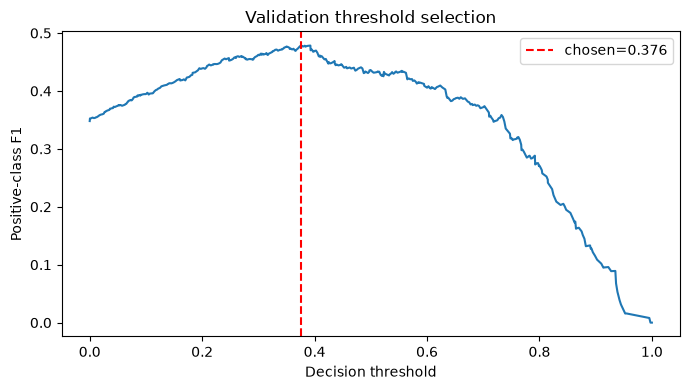

Validation confusion matrix (rows: actual 0/1; columns: predicted 0/1):


,predicted 0,predicted 1
actual 0,620,298
actual 1,74,171


In [8]:
winner_row = max(candidate_rows, key=lambda r: (r['average_precision'], r['balanced_accuracy']))
winner_name = winner_row['model']
if winner_name in variant_models:
    final_model, final_variant = variant_models[winner_name]
elif winner_name in tuned_models:
    final_model, final_variant = tuned_models[winner_name], 'all features'
else:
    final_model, final_variant = baseline_models[winner_name], 'all features'
X_val_final = feature_variant(X_val, final_variant)
val_scores = positive_score(final_model, X_val_final)
p, r, thresholds = precision_recall_curve(y_val, val_scores)
f1_by_threshold = 2 * p[:-1] * r[:-1] / np.maximum(p[:-1] + r[:-1], 1e-12)
best_index = int(np.argmax(f1_by_threshold))
chosen_threshold = float(thresholds[best_index])
val_preds = (val_scores >= chosen_threshold).astype(int)
selected_val_row = metric_row(y_val, val_scores, val_preds, winner_name, 'selected threshold validation')
experiment_rows.append(selected_val_row)
print('Selected:', winner_name)
print('Feature set:', final_variant)
print('Validation F1 threshold:', chosen_threshold)
show_results([winner_row, selected_val_row])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, f1_by_threshold)
ax.axvline(chosen_threshold, color='red', linestyle='--', label=f'chosen={chosen_threshold:.3f}')
ax.set(xlabel='Decision threshold', ylabel='Positive-class F1', title='Validation threshold selection')
ax.legend(); plt.tight_layout(); plt.show()
print('Validation confusion matrix (rows: actual 0/1; columns: predicted 0/1):')
display(pd.DataFrame(confusion_matrix(y_val, val_preds), index=['actual 0', 'actual 1'],
                     columns=['predicted 0', 'predicted 1']))

## 7. Interpret the selected model
Group permutation measures the drop in validation average precision when one original feature family is shuffled together. It preserves the one-hot structure within a family. Correlated feature families can share credit, so these values indicate predictive dependence, not causal effects.

In [9]:
def feature_group(column):
    if column.startswith('age__') or column.startswith('age_x_'):
        return 'age / age interactions'
    if column.startswith('flags_and_month__'):
        return 'missing-age flag / intake month'
    for family in ['type', 'breed', 'color', 'biological_sex', 'intake_type',
                   'intake_subtype', 'intake_condition', 'intake_jurisdiction']:
        if column.startswith('categories__' + family + '_'):
            return family
    return 'other'

groups = {}
for col in X_val_final.columns:
    groups.setdefault(feature_group(col), []).append(col)
base_ap = average_precision_score(y_val, positive_score(final_model, X_val_final))
rng = np.random.default_rng(RANDOM_STATE)
group_rows = []
for group, columns in groups.items():
    drops = []
    for _ in range(3):
        permuted = X_val_final.copy()
        order = rng.permutation(len(permuted))
        permuted.loc[:, columns] = permuted[columns].iloc[order].to_numpy()
        drops.append(base_ap - average_precision_score(y_val, positive_score(final_model, permuted)))
    group_rows.append({'feature_family': group, 'columns': len(columns),
                       'AP_drop_mean': np.mean(drops), 'AP_drop_sd': np.std(drops)})
importance_table = pd.DataFrame(group_rows).sort_values('AP_drop_mean', ascending=False)
display(importance_table.round(4))

,feature_family,columns,AP_drop_mean,AP_drop_sd
0,age / age interactions,9,0.1052,0.0091
8,intake_condition,5,0.0505,0.0121
1,missing-age flag / intake month,3,0.0499,0.0055
5,biological_sex,3,0.0304,0.0082
7,intake_subtype,16,0.0223,0.0024
4,color,63,0.0061,0.0078
9,intake_jurisdiction,12,0.0040,0.0009
3,breed,71,0.0026,0.0029
6,intake_type,6,-0.0010,0.0023
2,type,3,-0.0026,0.0017


## 8. Final locked test evaluation
The selected trained model and validation threshold are applied once to the untouched test split. Keeping the fitted training model preserves the meaning of the threshold selected on validation. Compare with the dummy and with positive prevalence. If performance falls on test, report the shift honestly; the long-stay rate differs substantially across splits.

,stage,model,accuracy,balanced_accuracy,precision_1,recall_1,f1_1,roc_auc,average_precision,fit_seconds
0,final test,Random forest tuned | age interactions,0.733,0.569,0.295,0.306,0.300,0.636,0.318,nan
1,test benchmark,Dummy majority,0.812,0.500,0.000,0.000,0.000,0.500,0.188,nan


Test prevalence / random-ranking AP reference: 0.188


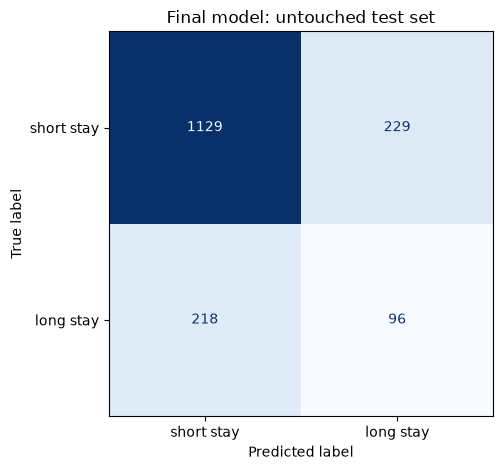

False negatives (missed long stays): 218
False positives (short stays flagged): 229


In [10]:
X_test_final = feature_variant(X_test, final_variant)
assert list(X_test_final.columns) == list(X_val_final.columns)
test_scores = positive_score(final_model, X_test_final)
test_preds = (test_scores >= chosen_threshold).astype(int)
test_row = metric_row(y_test, test_scores, test_preds, winner_name, 'final test')
dummy_test_row = evaluate_fitted(baseline_models['Dummy majority'], X_test, y_test,
                                 'Dummy majority', 'test benchmark')
experiment_rows.extend([test_row, dummy_test_row])
show_results([test_row, dummy_test_row])
print(f'Test prevalence / random-ranking AP reference: {y_test.mean():.3f}')
ConfusionMatrixDisplay.from_predictions(y_test, test_preds, display_labels=['short stay', 'long stay'],
                                        cmap='Blues', colorbar=False)
plt.title('Final model: untouched test set'); plt.tight_layout(); plt.show()
print('False negatives (missed long stays):', int(((y_test == 1) & (test_preds == 0)).sum()))
print('False positives (short stays flagged):', int(((y_test == 0) & (test_preds == 1)).sum()))

## 9. Evidence-based result summary
These statements are generated from the run. Use them as evidence, then add your own explanation of why the results differ.

In [11]:
real_baselines = [row for row in experiment_rows if row['stage'] == 'baseline validation'
                  and row['model'] != 'Dummy majority']
best_baseline = max(real_baselines, key=lambda row: row['average_precision'])
best_tuned = max((row for row in experiment_rows if row['stage'] == 'tuned validation'),
                 key=lambda row: row['average_precision'])
print(f"Best baseline: {best_baseline['model']} (validation AP {best_baseline['average_precision']:.3f}).")
print(f"Best tuned model: {best_tuned['model']} (validation AP {best_tuned['average_precision']:.3f}).")
print(f"Selected: {winner_name}, using {final_variant}; validation AP {winner_row['average_precision']:.3f}.")
print(f"At the chosen threshold, validation F1 is {selected_val_row['f1_1']:.3f} and recall is {selected_val_row['recall_1']:.3f}.")
print(f"Test: accuracy {test_row['accuracy']:.3f}, balanced accuracy {test_row['balanced_accuracy']:.3f}, AP {test_row['average_precision']:.3f}, long-stay recall {test_row['recall_1']:.3f}.")
print(f"Dummy test accuracy is {dummy_test_row['accuracy']:.3f}; dummy long-stay recall is {dummy_test_row['recall_1']:.3f}.")
print(f"Positive-class prevalence shifts from {y_train.mean():.1%} in train to {y_val.mean():.1%} in validation and {y_test.mean():.1%} in test.")
print('Explain any test decline, false negatives, and why the chosen metric fits the shelter use case.')

Best baseline: Gradient boosting (validation AP 0.375).
Best tuned model: Random forest tuned (validation AP 0.378).
Selected: Random forest tuned | age interactions, using age interactions; validation AP 0.387.
At the chosen threshold, validation F1 is 0.479 and recall is 0.698.


Test: accuracy 0.733, balanced accuracy 0.569, AP 0.318, long-stay recall 0.306.
Dummy test accuracy is 0.812; dummy long-stay recall is 0.000.
Positive-class prevalence shifts from 31.4% in train to 21.1% in validation and 18.8% in test.
Explain any test decline, false negatives, and why the chosen metric fits the shelter use case.


## 10. Experiment record and deliverables
The table includes the dummy benchmark, four baselines, tuned models, feature experiments, selected validation threshold, and final test comparison. Keep the outputs when submitting the notebook. The saved model bundle contains the feature order, selected variant, and threshold needed to reproduce predictions.

In [12]:
experiment_table = pd.DataFrame(experiment_rows)
display(experiment_table.round(4))
experiment_table.to_csv('Stage_6_7_8_experiment_log.csv', index=False)
joblib.dump({'model': final_model, 'feature_columns': list(X_val_final.columns),
             'variant': final_variant, 'threshold': chosen_threshold,
             'positive_class': 'long_stay_30 = 1'}, 'Stage_6_7_8_final_model.joblib')
print('Saved experiment log and final model bundle.')

,stage,model,n,accuracy,balanced_accuracy,precision_1,recall_1,f1_1,roc_auc,average_precision,fit_seconds
0,baseline train,Dummy majority,6096,0.6864,0.5000,0.0000,0.0000,0.0000,0.5000,0.3136,0.0480
1,baseline validation,Dummy majority,1163,0.7893,0.5000,0.0000,0.0000,0.0000,0.5000,0.2107,0.0480
2,baseline train,Logistic regression,6096,0.7823,0.7130,0.7044,0.5272,0.6031,0.8279,0.7032,0.0366
3,baseline validation,Logistic regression,1163,0.7111,0.6195,0.3565,0.4612,0.4021,0.6904,0.3496,0.0366
4,baseline train,Linear SVM,6096,0.7813,0.7132,0.6998,0.5303,0.6034,0.8274,0.7023,0.0366
5,baseline validation,Linear SVM,1163,0.7042,0.6092,0.3438,0.4449,0.3879,0.6802,0.3430,0.0366
6,baseline train,Random forest,6096,0.8406,0.8232,0.7315,0.7767,0.7534,0.9273,0.8589,0.9601
7,baseline validation,Random forest,1163,0.6698,0.6562,0.3452,0.6327,0.4467,0.7028,0.3610,0.9601
8,baseline train,Gradient boosting,6096,0.8435,0.7945,0.8035,0.6632,0.7266,0.9190,0.8564,1.0651
9,baseline validation,Gradient boosting,1163,0.7128,0.6550,0.3767,0.5551,0.4488,0.7134,0.3750,1.0651


Saved experiment log and final model bundle.


## 11. Stage 8: explain your own decisions
Fill in these points using the actual outputs above before presenting.

1. **Problem and baseline:** What does `long_stay_30` mean? Why is ordinary accuracy misleading here? Quote the dummy accuracy and its long-stay recall.
2. **Algorithm choices:** Explain what linear models, bagged trees, and boosted trees can capture in this one-hot dataset. Give one practical limitation of each.
3. **Validation:** Explain the fixed train/validation/test split, your `CV_MODE`, and why the test split was opened only after model and threshold selection. State whether row order truly represents time.
4. **Results:** Compare baseline and tuned AP, balanced accuracy, positive F1, and recall. Explain any train/validation gap and the drop or improvement on test.
5. **Optimization:** State the search budget, best parameters, feature variant results, and why the selected threshold was appropriate.
6. **Final choice:** Name the winning model, quote final test metrics and confusion matrix, and explain the performance-versus-interpretability trade-off.
7. **Your contribution and limitations:** Describe the modelling work you personally performed. Note the class-rate shift and the unresolved preprocessing-fit audit if you cannot verify it from the original preprocessing code.

**Interpretation rule:** feature importance indicates association in this dataset; it does not establish that a feature causes longer stays.